In [101]:
import numpy as np
import pandas as pd

In [102]:
df=pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [103]:
df.shape

(37249, 2)

In [104]:
df.sample()['clean_comment'].values

array(['pathetic attempt canvas votes hope apologize for this remark '],
      dtype=object)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [106]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [107]:
df[df['clean_comment'].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [108]:
df[df['clean_comment'].isna()]['category'].value_counts()

category
0    100
Name: count, dtype: int64

In [109]:
df.dropna(inplace=True)

In [110]:
df.duplicated().sum()

350

In [111]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [112]:
df.drop_duplicates(inplace=True)

In [113]:
df.duplicated().sum()

0

In [114]:
df[(df['clean_comment'].str.strip()=='')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [115]:
df=df[~(df['clean_comment'].str.strip()=='')]

In [116]:
# converting the clean_comment to lowercase
df['clean_comment'] = df['clean_comment'].str.lower()

In [117]:
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [118]:
df[df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [119]:
# removing trailing and leading whitespaces from the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].str.strip()
df['clean_comment'].apply(lambda x:x.endswith(' ') or x.startswith(' ')).sum()

0

In [120]:
url_pattern = r'http[s]://(?:[a-zA-Z]|[0-9]|[$=_@.&+]|[!*\\(\\),]|[?:%[0-9a-fA-F][0-9a-fA-F])+'


In [121]:
comments_with_urls=df[df['clean_comment'].str.contains(url_pattern,regex = True)]
comments_with_urls.head()

,clean_comment,category


In [122]:
comment_with_newline=df[df['clean_comment'].str.contains('\n')]
comment_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [123]:
df['clean_comment'] = df['clean_comment'].str.replace('\n',' ',regex=True)
comments_with_newline_remaining=df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining

,clean_comment,category


# EDA

<Axes: xlabel='category', ylabel='count'>

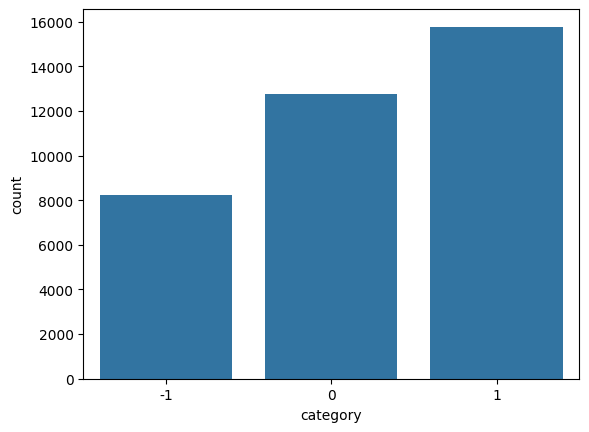

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt 
sns.countplot(data=df,x="category")

In [125]:
df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [126]:
df['word_count']=df['clean_comment'].apply(lambda x:len(x.split()))

In [127]:
df.sample(5)

,clean_comment,category,word_count
24742,awesome reply this getting bookmarked you are ...,1,10
31669,thanks for the disclosure otherwise you know,1,7
10593,first the limit only 5000 inr till the end the...,1,56
35389,from the lighting the power tube the left side...,-1,16
7800,have heard gujrat has the most amount sex goin...,1,12


In [128]:
df['word_count'].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

C:\Users\ROSY PAUL\AppData\Local\Temp\ipykernel_29988\2898084430.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['word_count'],kde=True)


<Axes: xlabel='word_count', ylabel='Density'>

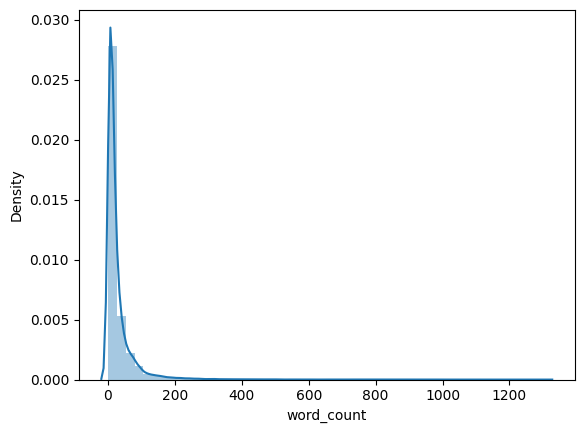

In [129]:
sns.distplot(df['word_count'],kde=True)

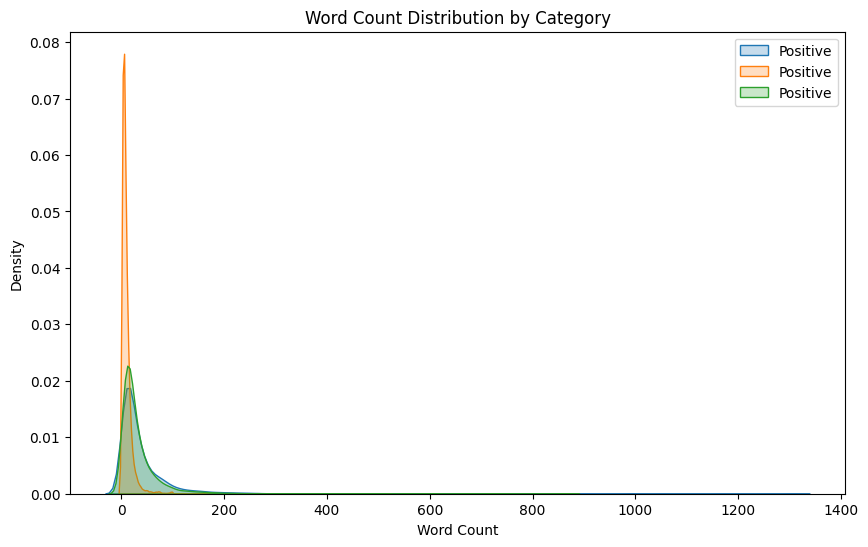

In [130]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[df['category']==1]['word_count'],label='Positive',fill=True)
sns.kdeplot(df[df['category']==0]['word_count'],label='Positive',fill=True)
sns.kdeplot(df[df['category']==-1]['word_count'],label='Positive',fill=True)

plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.legend()
plt.show()

<Axes: ylabel='word_count'>

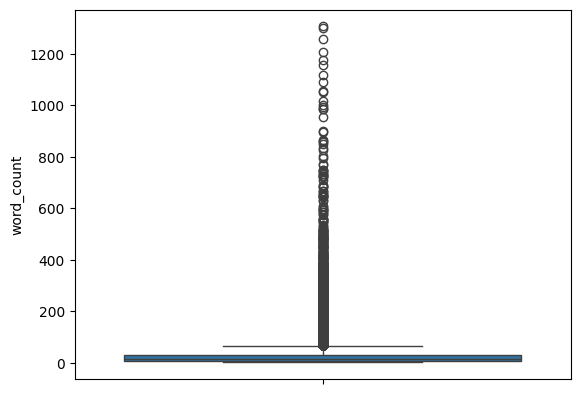

In [131]:
sns.boxplot(df['word_count'])

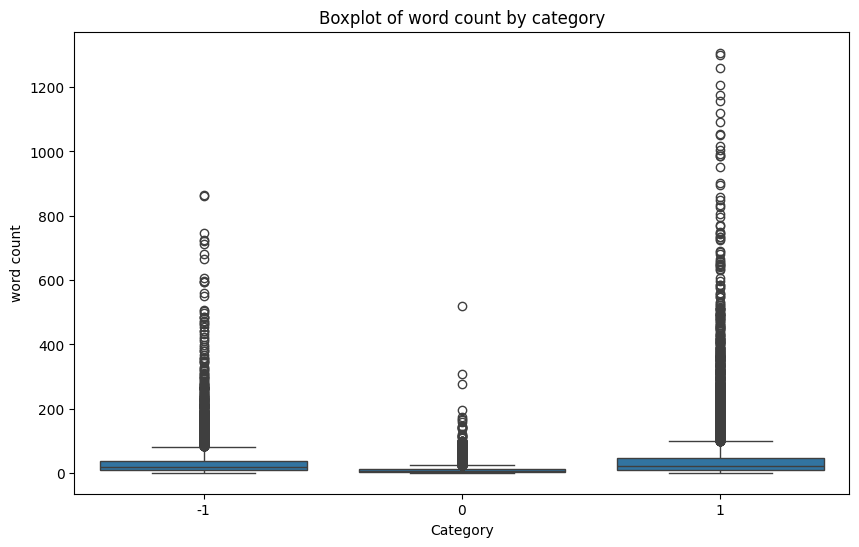

In [132]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="category",y="word_count")
plt.title('Boxplot of word count by category')
plt.xlabel('Category')
plt.ylabel('word count')
plt.show()

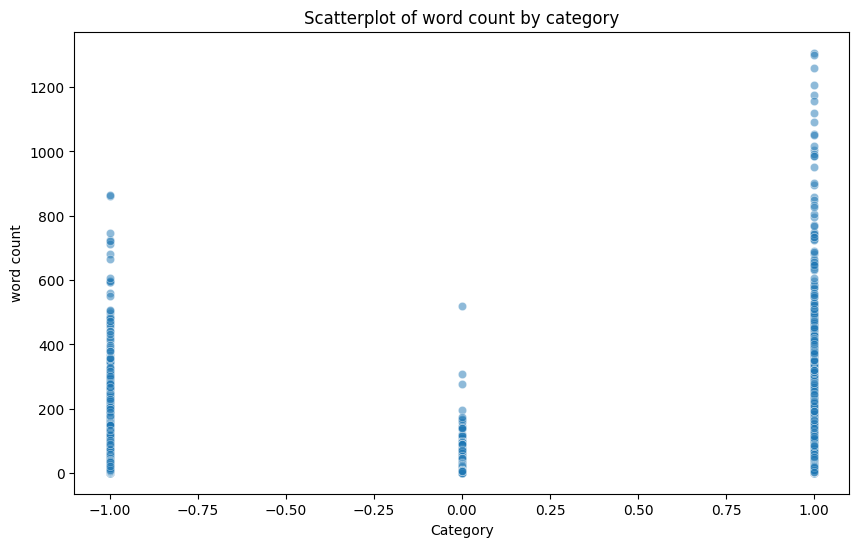

In [133]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="category",y="word_count",alpha=0.5)
plt.title('Scatterplot of word count by category')
plt.xlabel('Category')
plt.ylabel('word count')
plt.show()

,clean_comment,category,word_count,num_stop_words
0,family mormon have never tried explain them th...,1,39,13
1,buddhism has very much lot compatible with chr...,1,196,59
2,seriously don say thing first all they won get...,-1,86,40
3,what you have learned yours and only yours wha...,0,29,15
4,for your own benefit you may want read living ...,1,112,45


<Axes: xlabel='category', ylabel='word_count'>

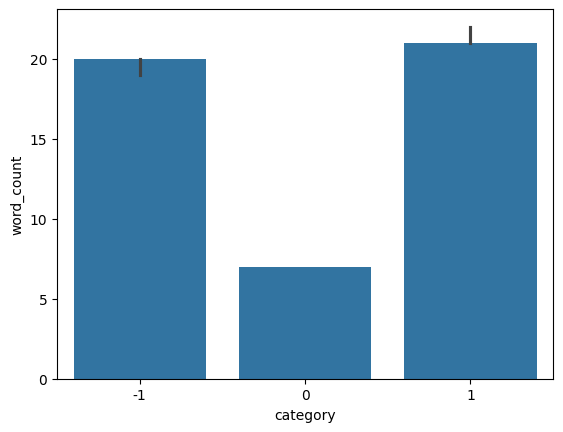

In [134]:

sns.barplot(data=df,x="category",y="word_count",estimator='median')


In [135]:
from nltk.corpus import stopwords

In [136]:
import nltk
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))
df['num_stop_words']=df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to C:\Users\ROSY
[nltk_data]     PAUL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [138]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
11893,occurs redpilling now may good time just like ...,1,116,46
21401,also love the dialogue after you beat the quee...,1,15,5
8517,those are the words for the wise,1,7,5
18063,yes pakistan interference was also the reason ...,-1,11,3
21896,imagine being dumb look the world around you a...,-1,24,9


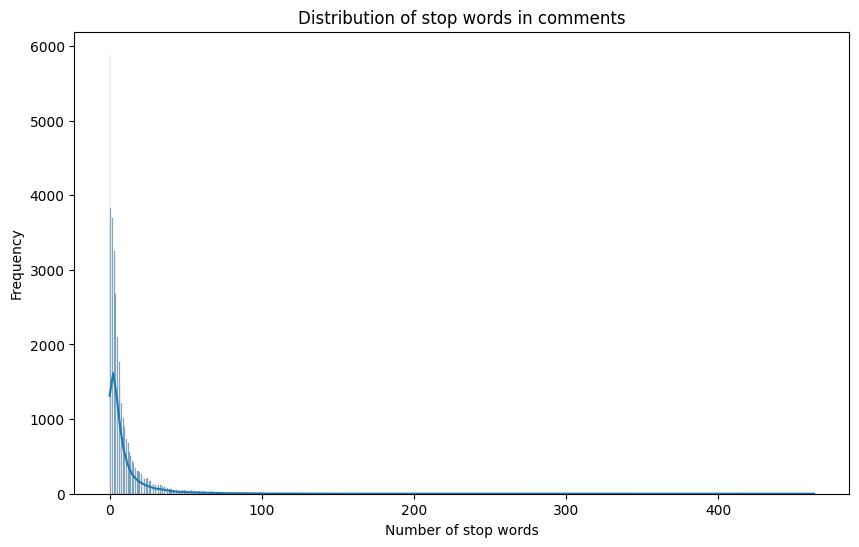

In [139]:
plt.figure(figsize=(10,6))
sns.histplot(df['num_stop_words'],kde=True)
plt.title('Distribution of stop words in comments')
plt.xlabel('Number of stop words')
plt.ylabel('Frequency')
plt.show()

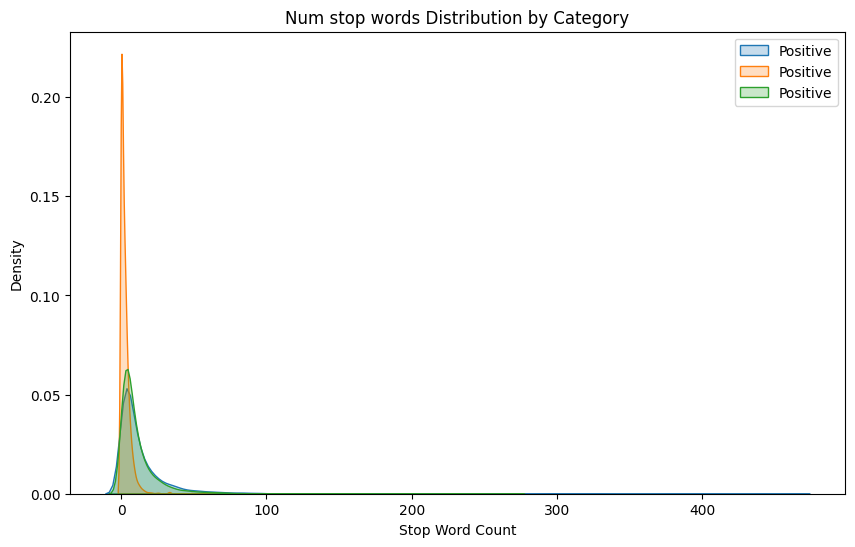

In [60]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[df['category']==1]['num_stop_words'],label='Positive',fill=True)
sns.kdeplot(df[df['category']==0]['num_stop_words'],label='Positive',fill=True)
sns.kdeplot(df[df['category']==-1]['num_stop_words'],label='Positive',fill=True)

plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop Word Count')
plt.ylabel('Density')
plt.legend()
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

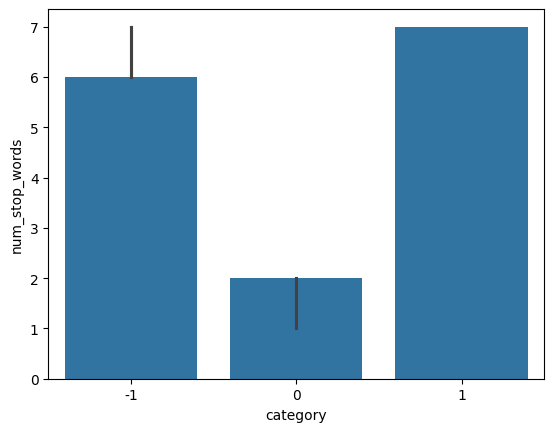

In [140]:

sns.barplot(data=df,x="category",y="num_stop_words",estimator='median')


C:\Users\ROSY PAUL\AppData\Local\Temp\ipykernel_29988\997101776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df,x='count',y='stop_word',palette='viridis')
C:\Users\ROSY PAUL\AppData\Local\Temp\ipykernel_29988\997101776.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


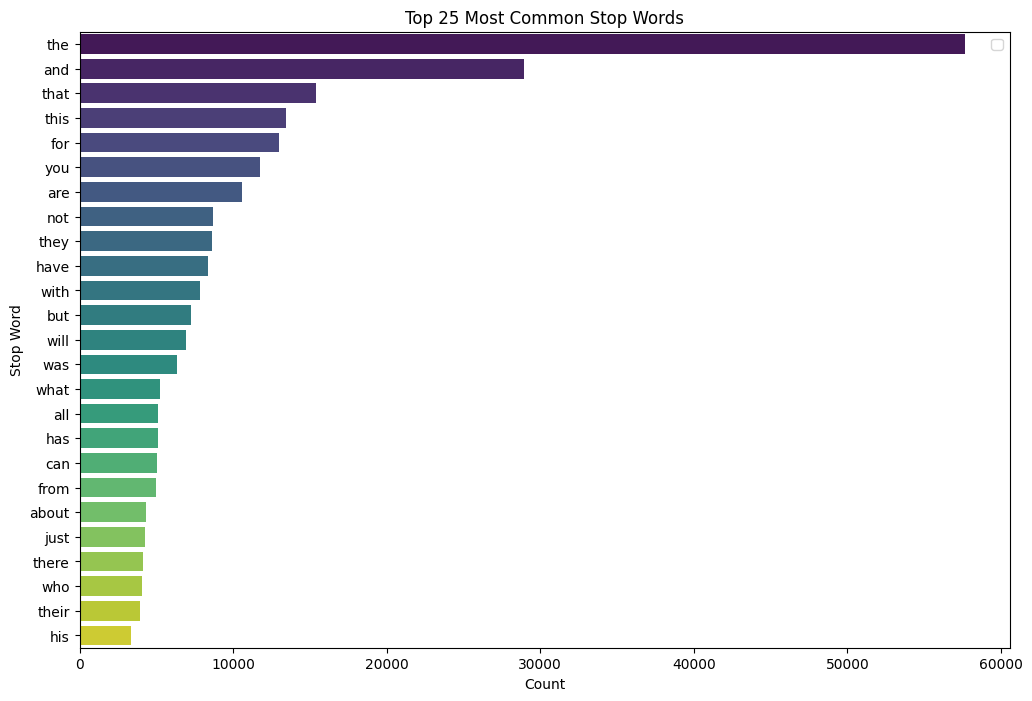

In [141]:
from collections import Counter
all_stop_words=[word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]
most_common_stop_words=Counter(all_stop_words).most_common(25)
top_25_df=pd.DataFrame(most_common_stop_words,columns=['stop_word','count'])
plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df,x='count',y='stop_word',palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.legend()
plt.show()

In [142]:
df['num_chars']=df['clean_comment'].apply(len)

In [143]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [144]:
df['num_chars'].describe()

count    36793.000000
mean       181.852798
std        359.702163
min          1.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: num_chars, dtype: float64

In [145]:
all_text=' '.join(df['clean_comment'])
char_frequency=Counter(all_text)
char_frequency_df=pd.DataFrame(char_frequency.items(),columns=['character','frequency']).sort_values(by='frequency',ascending=False)

In [146]:
char_frequency_df

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
...,...,...
999,丢,1
392,͞,1
997,援,1
996,哭,1


In [147]:
char_frequency_df['character'].values

array([' ', 'e', 't', ..., '援', '哭', '悼'], dtype=object)

In [148]:
df['num_punctuation_chars']=df['clean_comment'].apply(
    lambda x:sum([1 for char in x if char in '.!?;:"\'()[]{}-'])
)
df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
14001,until there not much big change think modi bet...,1,81,22,516,0
26886,hide the pain harold,0,4,1,20,0
18788,honest india the only country where you can ch...,1,35,8,193,0
2114,goddamn why there shourie but ananth kumar the...,-1,26,9,155,0
20694,the past couple days have broken down and feel...,-1,47,18,281,0


In [149]:
df['num_punctuation_chars'].describe()

count    36793.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punctuation_chars, dtype: float64

C:\Users\ROSY PAUL\AppData\Local\Temp\ipykernel_29988\249373533.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


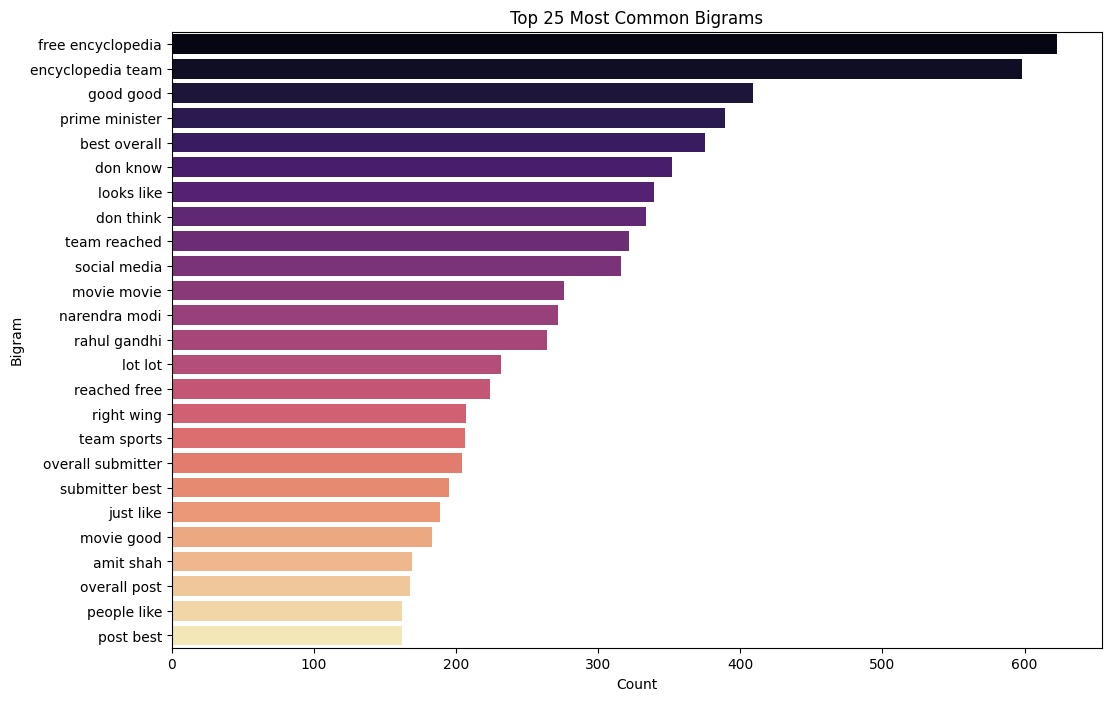

In [150]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)

top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

C:\Users\ROSY PAUL\AppData\Local\Temp\ipykernel_29988\1038956408.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='magma')


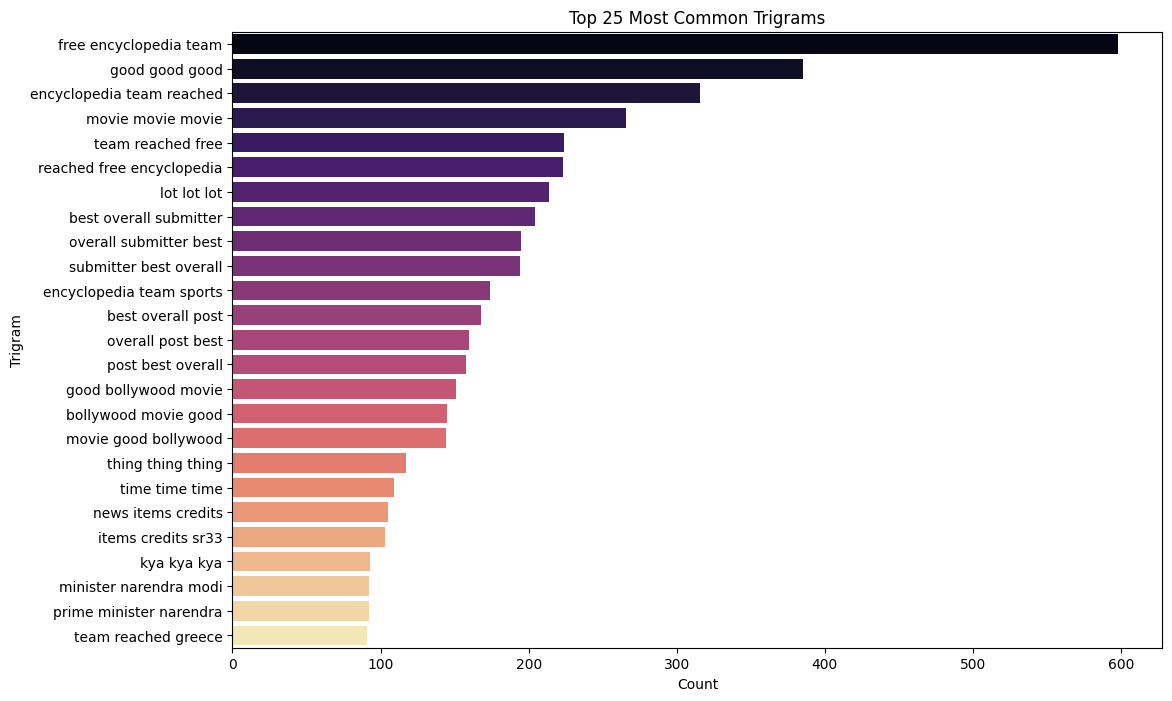

In [151]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a function to extract the top trigrams
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

# Convert trigrams into a DataFrame
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plot the trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='magma')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [152]:
import re
df['clean_comment']=df['clean_comment'].apply(lambda x:re.sub(r'[^A-Za-z0-9\s!?.,]','',str(x)))

In [153]:
all_text=' '.join(df['clean_comment'])
char_frequency=Counter(all_text)
char_frequency_df=pd.DataFrame(char_frequency.items(),columns=['character','frequency']).sort_values(by='frequency',ascending=False)
char_frequency_df

,character,frequency
6,,1091592
12,e,666610
13,t,491287
1,a,481134
3,i,401388
9,n,388465
7,o,379908
17,s,355279
8,r,331425
10,h,296748


In [154]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0


In [156]:
stop_words=set(stopwords.words('english'))-{'not','but','however','no','yet'}
df['clean_comment']=df['clean_comment'].apply(
    lambda x:' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [157]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [159]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer=WordNetLemmatizer()
df['clean_comment']=df['clean_comment'].apply(
    lambda x:' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)
df.head()

[nltk_data] Downloading package wordnet to C:\Users\ROSY
[nltk_data]     PAUL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


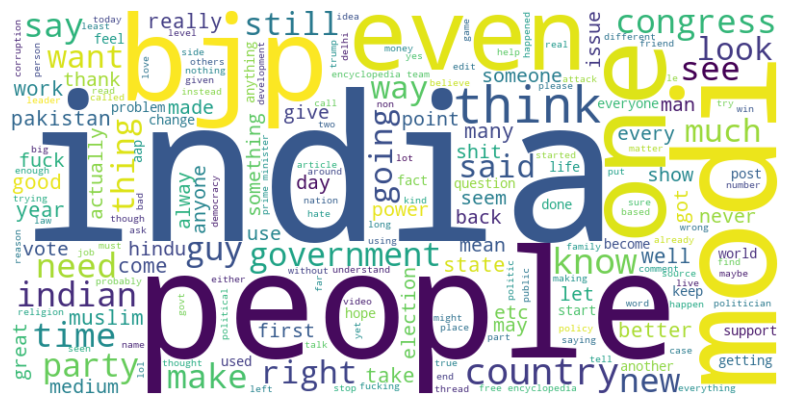

In [168]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
plot_word_cloud(df['clean_comment'])

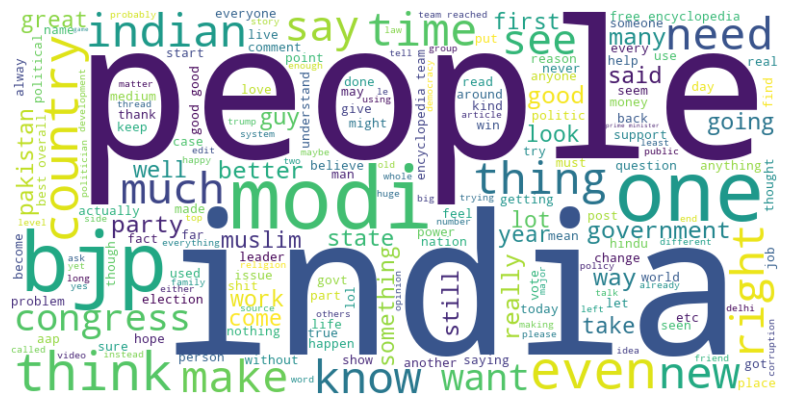

In [169]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
plot_word_cloud(df[df['category']==1]['clean_comment'])

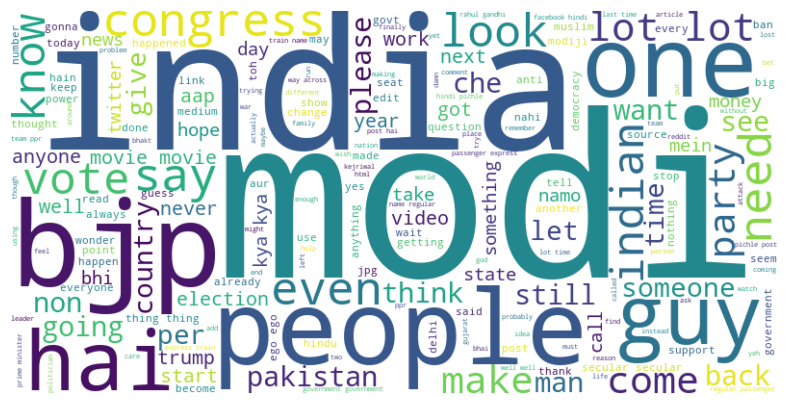

In [170]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
plot_word_cloud(df[df['category']==0]['clean_comment'])

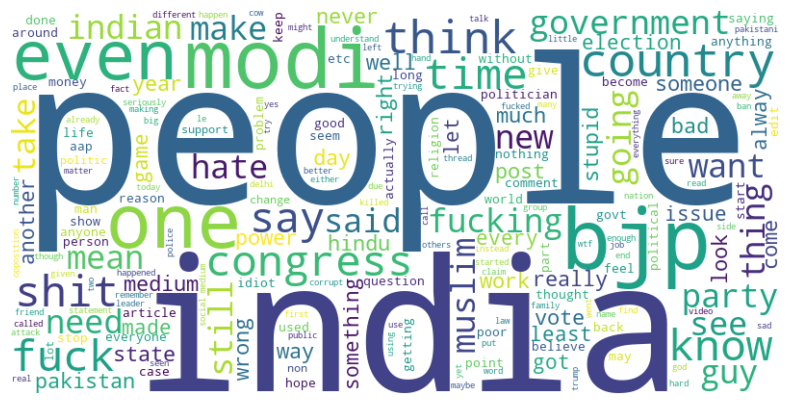

In [171]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()
plot_word_cloud(df[df['category']==-1]['clean_comment'])

In [175]:
def plot_top_n_words(df,n=50):
    words=' '.join(df['clean_comment']).split()
    counter=Counter(words)
    most_common_words =counter.most_common(n)
    words,count=zip(*most_common_words)
    plt.figure(figsize=(10,5))
    sns.barplot(x=list(count),y=list(words))
    plt.title(f'Top {n} Most frequent words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

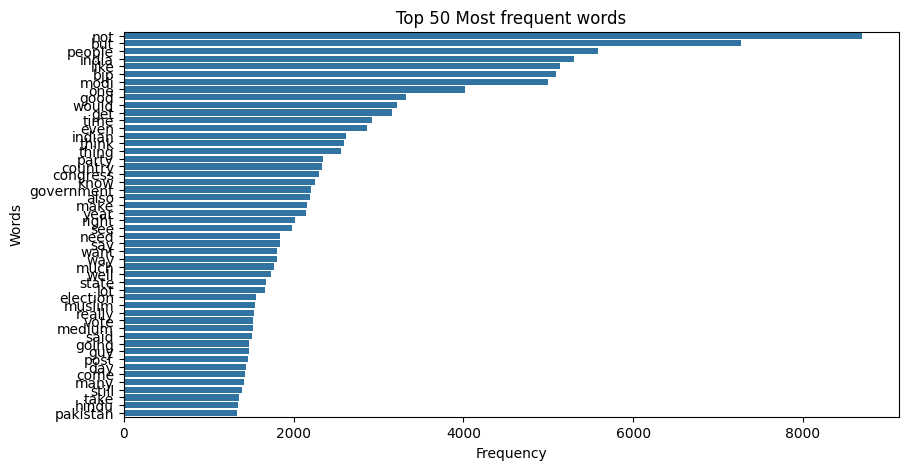

In [176]:
plot_top_n_words(df,n=50)

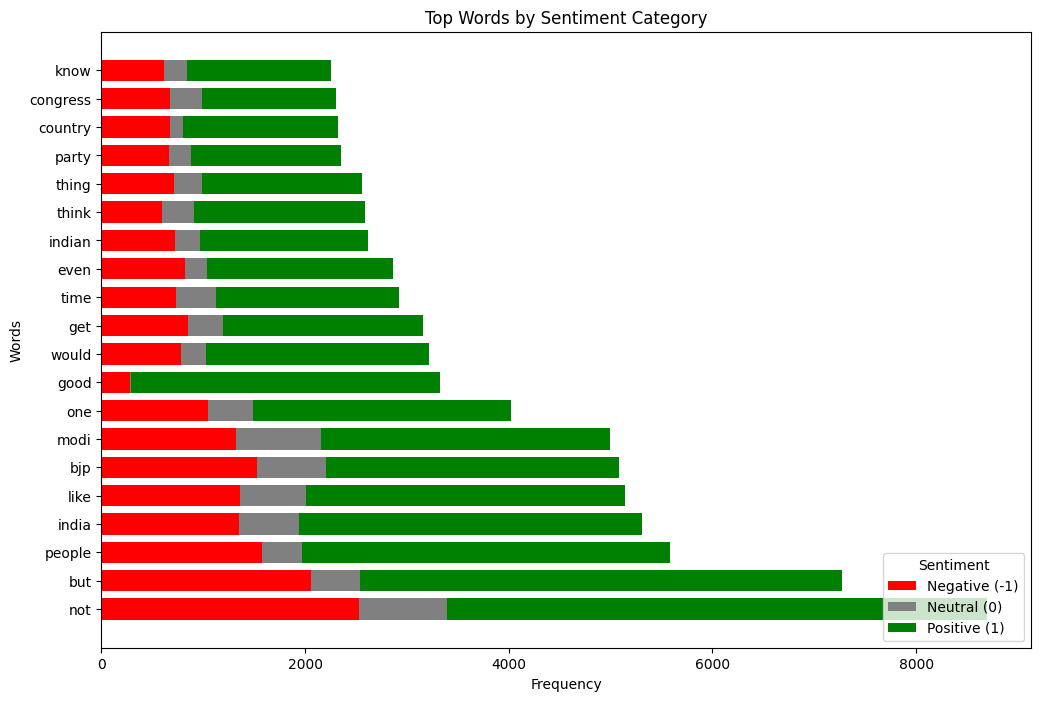

In [179]:


def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""

    # Flatten all words in the content column and count their occurrences by category
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']  # Assuming -1, 0, 1 labels exist

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = {-1: 0, 0: 0, 1: 0}

            word_category_counts[word][category] += 1

    # Get total counts across all categories for each word
    total_word_counts = {
        word: sum(counts.values()) for word, counts in word_category_counts.items()
    }

    # Get the top N most frequent words
    most_common_words = sorted(
        total_word_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )[start:start+n]

    top_words = [word for word, _ in most_common_words]

    # Prepare data for plotting
    word_labels = top_words

    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # Plot stacked bar chart
    plt.figure(figsize=(12,8))
    bar_width = 0.75

    # Plot negative, neutral, positive stacked bars
    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)

    plt.barh(word_labels, neutral_counts,
             left=negative_counts,
             color='gray',
             label='Neutral (0)',
             height=bar_width)

    plt.barh(word_labels, positive_counts,
             left=[i+j for i,j in zip(negative_counts, neutral_counts)],
             color='green',
             label='Positive (1)',
             height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')

    plt.legend(title='Sentiment', loc='lower right')

    plt.title('Top Words by Sentiment Category')

    plt.show()
plot_top_n_words_by_category(df,n=20)